<a href="https://colab.research.google.com/github/Randil01/DL_LAB2/blob/main/MLP_with_MNIST_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot as plt
import numpy as np
from tensorflow.keras.regularizers import l1, l2

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

Load the MNIST dataset

In [ ]:
(train_data,train_target),(test_data,test_target) = mnist.load_data()

Visualize the dataset

Target labels:  [7 1 8 0 7 9 3 6 2 2]


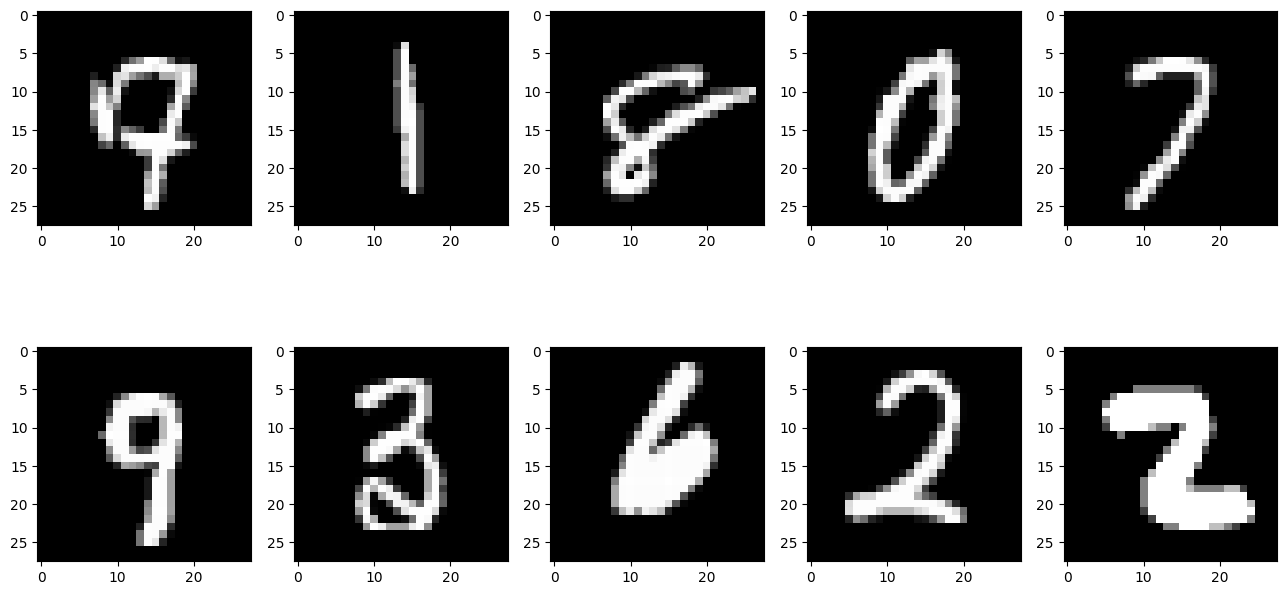

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(16,8))
random_numbers = np.random.randint(0, 60000, 10)
print('Target labels: ',train_target[random_numbers])
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(train_data[random_numbers[idx]],cmap='gray')
plt.show()

Pre-processing stage

In [ ]:
new_train_data = train_data/255.0
new_test_data=test_data/255.0

new_train_target = to_categorical(train_target)
new_test_target = to_categorical(test_target)

Create the Model architecture

In [ ]:
#L1
model = Sequential()

model.add(Flatten(input_shape=(28,28)))

model.add(Dense(128,
                activation='relu',
                kernel_regularizer=l1(0.001)))

model.add(Dense(64,
                activation='relu',
                kernel_regularizer=l1(0.001)))

model.add(Dense(32,
                activation='relu',
                kernel_regularizer=l1(0.001)))

model.add(Dense(10, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#L2
model = Sequential()

model.add(Flatten(input_shape=(28,28)))

model.add(Dense(128,
                activation='relu',
                kernel_regularizer=l2(0.001)))

model.add(Dense(64,
                activation='relu',
                kernel_regularizer=l2(0.001)))

model.add(Dense(32,
                activation='relu',
                kernel_regularizer=l2(0.001)))

model.add(Dense(10, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
train_info = model.fit(
    new_train_data,
    new_train_target,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9041 - loss: 0.3243 - val_accuracy: 0.9542 - val_loss: 0.1535
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9623 - loss: 0.1247 - val_accuracy: 0.9647 - val_loss: 0.1169
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9738 - loss: 0.0863 - val_accuracy: 0.9660 - val_loss: 0.1150
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9798 - loss: 0.0643 - val_accuracy: 0.9723 - val_loss: 0.0969
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9842 - loss: 0.0486 - val_accuracy: 0.9730 - val_loss: 0.0941
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9876 - loss: 0.0400 - val_accuracy: 0.9728 - val_loss: 0.1009
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9896 - loss: 0.0329 - val_accuracy: 0.9727 - val_loss: 0.1045
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9916 - loss: 0.0264 - val_accuracy: 0.

KeyboardInterrupt: 

In [ ]:
model=Sequential()

model.add(Flatten(input_shape=(28,28)))

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
model.summary()

Train the model

In [ ]:
train_info = model.fit(new_train_data , new_train_target , epochs = 10)

In [ ]:
#confusion matrix
predictions = model.predict(new_test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(new_test_target, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Plot the loss and accuracy graphs

In [ ]:
plt.plot(train_info.history['loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Model loss')
plt.show()

In [ ]:
plt.plot(train_info.history['accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Model accuracy')
plt.show()

Test the performance of Model

In [ ]:
loss, acc = model.evaluate(new_test_data , new_test_target)
print(f'Loss of the Test dataset is: {loss}\nAccuracy of the test dataset is: {acc}')

Save the model weights

In [ ]:
model.save_weights('MNIST_WEIGHTS_V1.h5')